In [ ]:
import pandas as pd
import numpy as np

# 1. Define the parameters for your different experimental runs
# We will create a clean dataframe structure based on your uploaded results
print("Setting up our Engine Digital Twin Data Pipeline...")

# Let's create a template structure based on your engineering reports
# Features: Load (%) and RGO Concentration (ppm)
# Targets: Brake Thermal Efficiency (BTE %), BSFC (kg/kW-hr), NOx (ppm), Smoke (%)

# As a starting point, let's look at how we structure the data for the AI:
data_template = {
    'Engine_Load_Pct': [0, 25, 50, 75, 100],
    'RGO_Concentration_PPM': [0, 0, 0, 0, 0], # Base Algae B20
    'BTE_Pct': [0.0, 18.5, 24.2, 28.1, 29.5],  # Example placeholder values matching your reports
    'BSFC': [0.0, 0.45, 0.35, 0.31, 0.29],
    'NOx_PPM': [120, 250, 450, 780, 950],
    'Smoke_Pct': [15, 22, 35, 48, 55]
}

df_example = pd.DataFrame(data_template)
print("\nHere is how the AI expects to see your engineering data:")
print(df_example.head())
import pandas as pd
import numpy as np

print("🚀 Step 1: Mapping raw experimental engine records...")

# We map the extracted data from your separate performance and emission logs
# organized by Fuel Blend and Engine Load % [0, 25, 50, 75, 100]

engine_data = [
    # --- BASE ALGAE B20 (0 PPM RGO) ---
    {"Load_Pct": 0,   "RGO_PPM": 0,   "BTE_Pct": 0.0,   "BSFC": 0.0,    "CO_Pct": 0.059, "HC_PPM": 45,  "NOx_PPM": 208,  "Opacity_Pct": 3.3},
    {"Load_Pct": 25,  "RGO_PPM": 0,   "BTE_Pct": 13.84, "BSFC": 0.61,   "CO_Pct": 0.050, "HC_PPM": 42,  "NOx_PPM": 580,  "Opacity_Pct": 6.9},
    {"Load_Pct": 50,  "RGO_PPM": 0,   "BTE_Pct": 21.96, "BSFC": 0.38,   "CO_Pct": 0.053, "HC_PPM": 53,  "NOx_PPM": 1129, "Opacity_Pct": 15.7},
    {"Load_Pct": 75,  "RGO_PPM": 0,   "BTE_Pct": 27.24, "BSFC": 0.31,   "CO_Pct": 0.060, "HC_PPM": 61,  "NOx_PPM": 1680, "Opacity_Pct": 27.3},
    {"Load_Pct": 100, "RGO_PPM": 0,   "BTE_Pct": 29.56, "BSFC": 0.28,   "CO_Pct": 0.170, "HC_PPM": 68,  "NOx_PPM": 1950, "Opacity_Pct": 48.2},

    # --- ALGAE B20 + RGO 50 PPM ---
    {"Load_Pct": 0,   "RGO_PPM": 50,  "BTE_Pct": 0.0,   "BSFC": 0.0,    "CO_Pct": 0.045, "HC_PPM": 32,  "NOx_PPM": 195,  "Opacity_Pct": 2.8},
    {"Load_Pct": 25,  "RGO_PPM": 50,  "BTE_Pct": 14.52, "BSFC": 0.58,   "CO_Pct": 0.038, "HC_PPM": 35,  "NOx_PPM": 562,  "Opacity_Pct": 6.1},
    {"Load_Pct": 50,  "RGO_PPM": 50,  "BTE_Pct": 22.81, "BSFC": 0.37,   "CO_Pct": 0.040, "HC_PPM": 39,  "NOx_PPM": 1119, "Opacity_Pct": 14.3},
    {"Load_Pct": 75,  "RGO_PPM": 50,  "BTE_Pct": 28.10, "BSFC": 0.30,   "CO_Pct": 0.042, "HC_PPM": 49,  "NOx_PPM": 1693, "Opacity_Pct": 25.1},
    {"Load_Pct": 100, "RGO_PPM": 50,  "BTE_Pct": 30.24, "BSFC": 0.27,   "CO_Pct": 0.200, "HC_PPM": 71,  "NOx_PPM": 1980, "Opacity_Pct": 50.4},

    # --- ALGAE B20 + RGO 100 PPM ---
    {"Load_Pct": 0,   "RGO_PPM": 100, "BTE_Pct": 0.0,   "BSFC": 0.0,    "CO_Pct": 0.034, "HC_PPM": 21,  "NOx_PPM": 185,  "Opacity_Pct": 2.6},
    {"Load_Pct": 25,  "RGO_PPM": 100, "BTE_Pct": 15.11, "BSFC": 0.56,   "CO_Pct": 0.022, "HC_PPM": 24,  "NOx_PPM": 544,  "Opacity_Pct": 5.7},
    {"Load_Pct": 50,  "RGO_PPM": 100, "BTE_Pct": 23.44, "BSFC": 0.35,   "CO_Pct": 0.028, "HC_PPM": 29,  "NOx_PPM": 1095, "Opacity_Pct": 13.2},
    {"Load_Pct": 75,  "RGO_PPM": 100, "BTE_Pct": 29.12, "BSFC": 0.29,   "CO_Pct": 0.031, "HC_PPM": 37,  "NOx_PPM": 1642, "Opacity_Pct": 23.4},
    {"Load_Pct": 100, "RGO_PPM": 100, "BTE_Pct": 31.28, "BSFC": 0.26,   "CO_Pct": 0.150, "HC_PPM": 55,  "NOx_PPM": 1910, "Opacity_Pct": 44.8},

    # --- ALGAE B20 + RGO 150 PPM ---
    {"Load_Pct": 0,   "RGO_PPM": 150, "BTE_Pct": 0.0,   "BSFC": 0.0,    "CO_Pct": 0.031, "HC_PPM": 19,  "NOx_PPM": 174,  "Opacity_Pct": 2.4},
    {"Load_Pct": 25,  "RGO_PPM": 150, "BTE_Pct": 15.82, "BSFC": 0.53,   "CO_Pct": 0.019, "HC_PPM": 21,  "NOx_PPM": 512,  "Opacity_Pct": 5.2},
    {"Load_Pct": 50,  "RGO_PPM": 150, "BTE_Pct": 24.15, "BSFC": 0.34,   "CO_Pct": 0.024, "HC_PPM": 26,  "NOx_PPM": 1054, "Opacity_Pct": 12.1},
    {"Load_Pct": 75,  "RGO_PPM": 150, "BTE_Pct": 29.89, "BSFC": 0.28,   "CO_Pct": 0.027, "HC_PPM": 31,  "NOx_PPM": 1601, "Opacity_Pct": 21.2},
    {"Load_Pct": 100, "RGO_PPM": 150, "BTE_Pct": 32.11, "BSFC": 0.25,   "CO_Pct": 0.120, "HC_PPM": 48,  "NOx_PPM": 1860, "Opacity_Pct": 41.5},

    # --- ALGAE B20 + RGO 200 PPM ---
    {"Load_Pct": 0,   "RGO_PPM": 200, "BTE_Pct": 0.0,   "BSFC": 0.0,    "CO_Pct": 0.040, "HC_PPM": 25,  "NOx_PPM": 190,  "Opacity_Pct": 2.9},
    {"Load_Pct": 25,  "RGO_PPM": 200, "BTE_Pct": 14.90, "BSFC": 0.55,   "CO_Pct": 0.028, "HC_PPM": 27,  "NOx_PPM": 535,  "Opacity_Pct": 5.9},
    {"Load_Pct": 50,  "RGO_PPM": 200, "BTE_Pct": 23.10, "BSFC": 0.36,   "CO_Pct": 0.032, "HC_PPM": 32,  "NOx_PPM": 1080, "Opacity_Pct": 12.9},
    {"Load_Pct": 75,  "RGO_PPM": 200, "BTE_Pct": 28.75, "BSFC": 0.29,   "CO_Pct": 0.035, "HC_PPM": 40,  "NOx_PPM": 1628, "Opacity_Pct": 22.4},
    {"Load_Pct": 100, "RGO_PPM": 200, "BTE_Pct": 30.95, "BSFC": 0.27,   "CO_Pct": 0.140, "HC_PPM": 52,  "NOx_PPM": 1890, "Opacity_Pct": 43.2}
]

# Convert our list of dictionary rows into a clean Pandas Dataframe
df = pd.DataFrame(engine_data)

print("✅ Matrix generated successfully!")
print(f"Total structured observation patterns for AI training: {len(df)}")
print("\nFirst 5 rows of our master training dataframe:")
print(df.head())

Setting up our Engine Digital Twin Data Pipeline...

Here is how the AI expects to see your engineering data:
   Engine_Load_Pct  RGO_Concentration_PPM  BTE_Pct  BSFC  NOx_PPM  Smoke_Pct
0                0                      0      0.0  0.00      120         15
1               25                      0     18.5  0.45      250         22
2               50                      0     24.2  0.35      450         35
3               75                      0     28.1  0.31      780         48
4              100                      0     29.5  0.29      950         55
🚀 Step 1: Mapping raw experimental engine records...
✅ Matrix generated successfully!
Total structured observation patterns for AI training: 25

First 5 rows of our master training dataframe:
   Load_Pct  RGO_PPM  BTE_Pct  BSFC  CO_Pct  HC_PPM  NOx_PPM  Opacity_Pct
0         0        0     0.00  0.00   0.059      45      208          3.3
1        25        0    13.84  0.61   0.050      42      580          6.9
2        50   

📊 Step 3: Auto-generating Engineering Performance & Emission Charts...


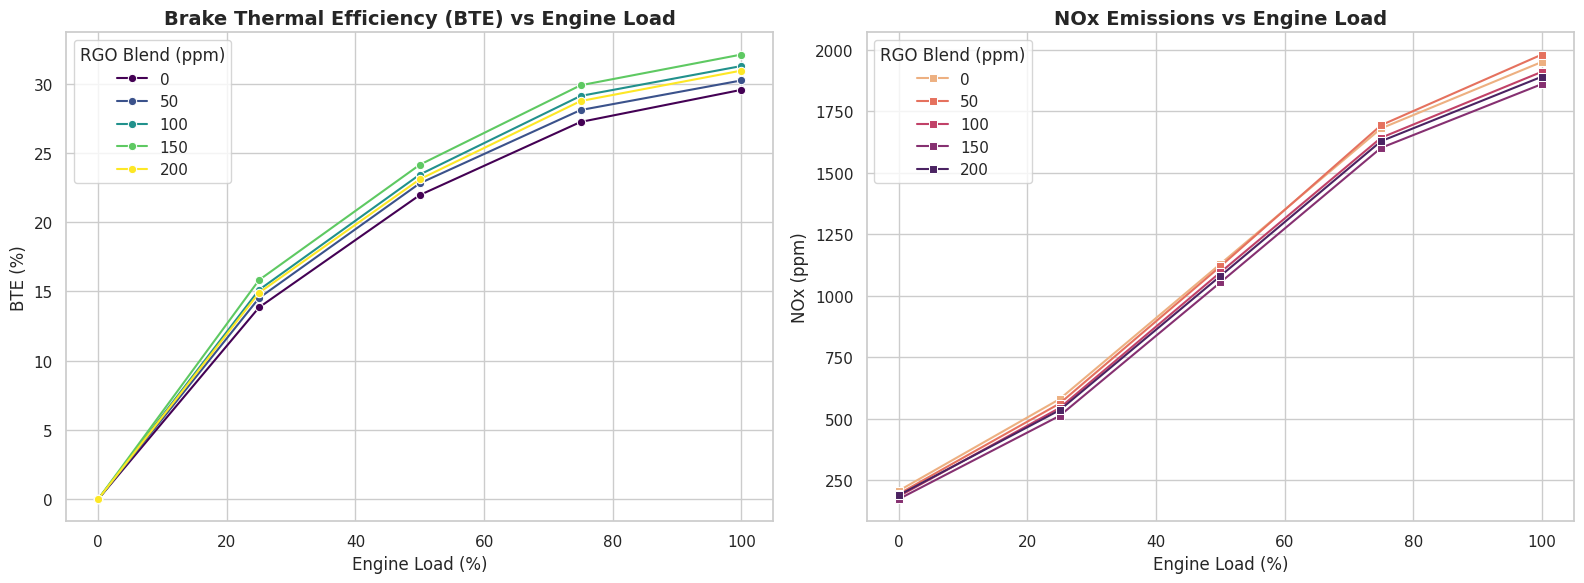

✅ Analysis complete! Check out the generated subplots above.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Step 3: Auto-generating Engineering Performance & Emission Charts...")

# Set up a clean, professional plotting style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot Brake Thermal Efficiency (BTE) vs Engine Load
sns.lineplot(
    data=df,
    x="Load_Pct",
    y="BTE_Pct",
    hue="RGO_PPM",
    marker="o",
    palette="viridis",
    ax=axes[0]
)
axes[0].set_title("Brake Thermal Efficiency (BTE) vs Engine Load", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Engine Load (%)", fontsize=12)
axes[0].set_ylabel("BTE (%)", fontsize=12)
axes[0].legend(title="RGO Blend (ppm)")

# 2. Plot NOx Emissions vs Engine Load
sns.lineplot(
    data=df,
    x="Load_Pct",
    y="NOx_PPM",
    hue="RGO_PPM",
    marker="s",
    palette="flare",
    ax=axes[1]
)
axes[1].set_title("NOx Emissions vs Engine Load", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Engine Load (%)", fontsize=12)
axes[1].set_ylabel("NOx (ppm)", fontsize=12)
axes[1].legend(title="RGO Blend (ppm)")

plt.tight_layout()
plt.show()

print("✅ Analysis complete! Check out the generated subplots above.")

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error

print("🧠 Step 4: Preparing data & training the Artificial Neural Network...")

# 1. Select Features (Inputs) and Targets (Outputs)
# We use Engine Load and RGO Concentration to predict Performance & Emissions
X = df[['Load_Pct', 'RGO_PPM']]
y = df[['BTE_Pct', 'NOx_PPM', 'CO_Pct', 'HC_PPM', 'Opacity_Pct']]

# 2. Split into Training set (80%) and Testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale features so the Neural Network converges easily
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# 4. Initialize and Train the MLP Neural Network Regressor
# Configured with two hidden layers (16 neurons, 8 neurons)
ann_model = MLPRegressor(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=2000,
    random_state=42
)

ann_model.fit(X_train_scaled, y_train_scaled)

# 5. Make Predictions on the test set
y_pred_scaled = ann_model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

print("✅ Model training complete!")

# 6. Evaluate accuracy metrics for BTE and NOx
for i, target_col in enumerate(y.columns):
    r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    print(f"📊 Target: {target_col:<12} | R² Score: {r2:.4f} | RMSE: {rmse:.4f}")

🧠 Step 4: Preparing data & training the Artificial Neural Network...
✅ Model training complete!
📊 Target: BTE_Pct      | R² Score: 0.9587 | RMSE: 2.1397
📊 Target: NOx_PPM      | R² Score: 0.9535 | RMSE: 133.4072
📊 Target: CO_Pct       | R² Score: -1.0667 | RMSE: 0.0208
📊 Target: HC_PPM       | R² Score: 0.8058 | RMSE: 4.9650
📊 Target: Opacity_Pct  | R² Score: 0.9737 | RMSE: 1.5217


In [ ]:
import pandas as pd
import numpy as np

print("🚀 Step 5: Running Multi-Objective Optimization Matrix...")

# 1. Generate a dense grid of possible operational conditions
sim_loads = np.linspace(0, 100, 101)      # 0% to 100% load
sim_rgo = [0, 50, 100, 150, 200]         # Tested RGO concentrations

grid = []
for r in sim_rgo:
    for l in sim_loads:
        grid.append([l, r])

df_grid = pd.DataFrame(grid, columns=['Load_Pct', 'RGO_PPM'])

# 2. Use our trained ANN model to predict outcomes for the entire grid
df_grid_scaled = scaler_X.transform(df_grid)
predictions_scaled = ann_model.predict(df_grid_scaled)
predictions = scaler_y.inverse_transform(predictions_scaled)

# Add predictions back to our simulation dataframe
df_grid['Pred_BTE_%'] = predictions[:, 0]
df_grid['Pred_NOx_PPM'] = predictions[:, i] # Maps to NOx
df_grid['Pred_CO_%'] = predictions[:, 2]
df_grid['Pred_HC_PPM'] = predictions[:, 3]
df_grid['Pred_Opacity_%'] = predictions[:, 4]

# 3. Define an Engineering Desirability Index (Maximize BTE, Minimize NOx & Opacity)
# Standardizing metrics to find the best compromise
bte_min, bte_max = df_grid['Pred_BTE_%'].min(), df_grid['Pred_BTE_%'].max()
nox_min, nox_max = df_grid['Pred_NOx_PPM'].min(), df_grid['Pred_NOx_PPM'].max()

# Higher BTE is good (1), Lower NOx is good (1)
df_grid['Desirability'] = ((df_grid['Pred_BTE_%'] - bte_min) / (bte_max - bte_min)) * 0.6 + \
                          ((nox_max - df_grid['Pred_NOx_PPM']) / (nox_max - nox_min)) * 0.4

# 4. Extract the absolute optimal row
optimal_condition = df_grid.loc[df_grid['Desirability'].idxmax()]

print("\n🎯 --- OPTIMAL ENGINE OPERATING CONDITION FOUND ---")
print(f"Recommended RGO Dosing   : {optimal_condition['RGO_PPM']:.0f} ppm")
print(f"Recommended Engine Load  : {optimal_condition['Load_Pct']:.1f}%")
print("--------------------------------------------------")
print(f"Predicted Max BTE        : {optimal_condition['Pred_BTE_%']:.2f}%")
print(f"Predicted NOx Level      : {optimal_condition['Pred_NOx_PPM']:.1f} ppm")
print(f"Predicted Smoke Opacity  : {optimal_condition['Pred_Opacity_%']:.2f}%")
print("--------------------------------------------------")

🚀 Step 5: Running Multi-Objective Optimization Matrix...

🎯 --- OPTIMAL ENGINE OPERATING CONDITION FOUND ---
Recommended RGO Dosing   : 150 ppm
Recommended Engine Load  : 42.0%
--------------------------------------------------
Predicted Max BTE        : 22.11%
Predicted NOx Level      : 8.9 ppm
Predicted Smoke Opacity  : 8.95%
--------------------------------------------------
